In [22]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import expon, skew, norm, probplot
from scipy import integrate
import seaborn as sns
import math

plt.rcParams['figure.figsize'] = [15, 7]
import warnings

warnings.filterwarnings('ignore')

In [23]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c':
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # index knn and the distance of each value
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) #normalize the values
        means = np.mean(arr) # exp function mean value
        inMean = 1 / means
        posNeg4 = []
        params = expon.fit(arr)
        spaceStep4 = np.linspace(.9,.99,20) # perform steps from .95 to .99
        for e in spaceStep4:
            #ker = -means * np.log(1 - e) # the percentile
            #f = integrate.quad(lambda x: inMean * np.exp(-x * inMean), 0, ker)
            #newArr = arr > ker # return a new array of values bigger than the percentile
            newArr = arr > expon.ppf(e,loc=params[0],scale=params[1])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def outputResultsArt(X,y,lowerRange=2,upperRange=70,checkValue=1):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # index knn and the distance of each value
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="medMax")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) #normalize the values
        means = np.mean(arr) # exp function mean value
        inMean = 1 / means
        posNeg4 = []
        params = expon.fit(arr)
        spaceStep4 = np.linspace(.9,.99,20) # perform steps from .95 to .99
        for e in spaceStep4:
            #ker = -means * np.log(1 - e) # the percentile
            #f = integrate.quad(lambda x: inMean * np.exp(-x * inMean), 0, ker)
            #newArr = arr > ker # return a new array of values bigger than the percentile
            newArr = arr > expon.ppf(e,loc=params[0],scale=params[1])
            posNeg4.append([((y[newArr] == checkValue).sum() / (y == checkValue).sum()), (y[newArr] != checkValue).sum()/ ((y != checkValue).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        arrtest1 = arrtest1.flatten()
        arrtest2 = arrtest2.flatten()
        arrtest1 = (arrtest1-np.min(arrtest1))/(np.max(arrtest1)-np.min(arrtest1)) # normalize the results for ease of use
        arrtest2 = (arrtest2-np.min(arrtest2))/(np.max(arrtest2)-np.min(arrtest2))
        arrtest2 = np.nan_to_num(arrtest2)
        if np.sum(arrtest2) == 0: # if there are zero false positives than return zero
            tots += [1]
        else:
            tots += [integrate.trapezoid(arrtest1, x=-arrtest2)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = expon.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = expon.pdf(newX, loc=params[0], scale=params[1]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

def ksTestArr(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = expon.fit(arr)
    results = stats.kstest(arr, expon.cdf,args=(params[0],params[1]))
    print(f"Loc: {params[0]}, scale: {params[1]}")
    print(f"stats: {results[0]}, p-value:{results[1]}")
    plt.hist(arr,bins=50)
    plt.title(name)
    plt.show()

def ksTestNorm(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = stats.skewnorm.fit(arr)
    results = stats.kstest(arr, stats.skewnorm.cdf,args=(params[0],params[1],params[2]))
    print(f"stats: {results[0]}, p-value:{results[1]}")

def qqPlots(X,y,kValue, name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = expon.fit(arr)
    results = probplot(arr,dist=stats.expon, plot=plt,sparams=(params[0],params[1]))
    plt.title(name)
    plt.show()

1.0 2 [1.0, 1.0, 0.9705882352941175, 0.9705882352941175, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
1.4586029968541372
[0.76291462 0.62577559 0.51328822 0.42102122 0.34533983 0.28326267
 0.2323443  0.19057886 0.15632103 0.12822127 0.10517264 0.08626715
 0.07076005 0.05804046 0.04760729 0.03904956 0.03203014 0.02627251
 0.02154985 0.01767612 0.01449872]
0.49860283458368926


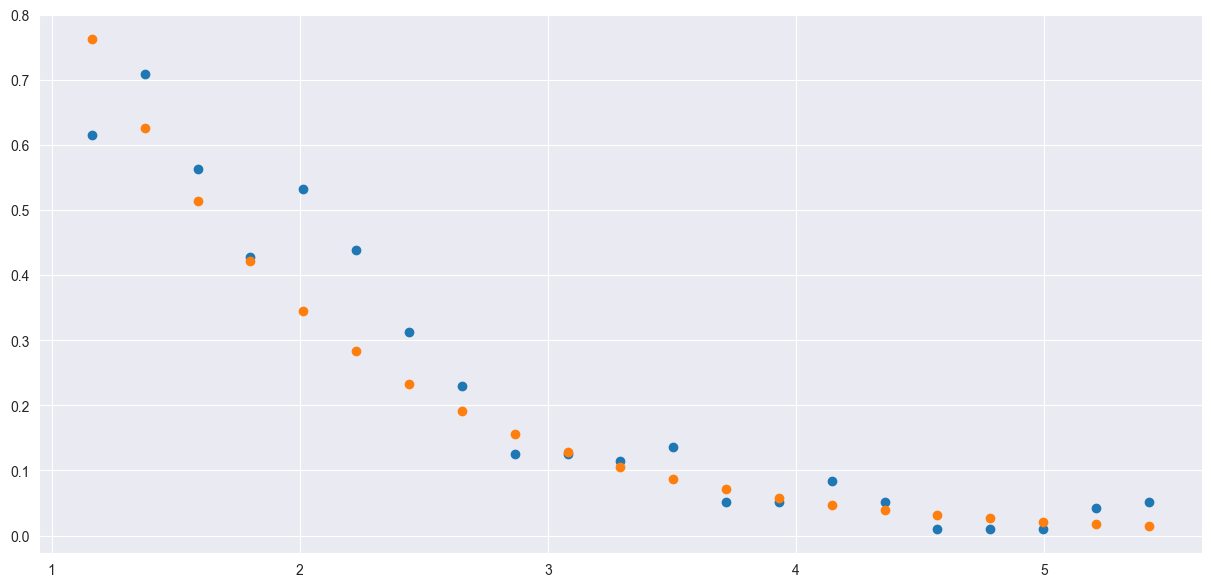

Loc: 1.161907363026888, scale: 1.0751442763068413
stats: 0.07726700921263968, p-value:0.008772714879874827


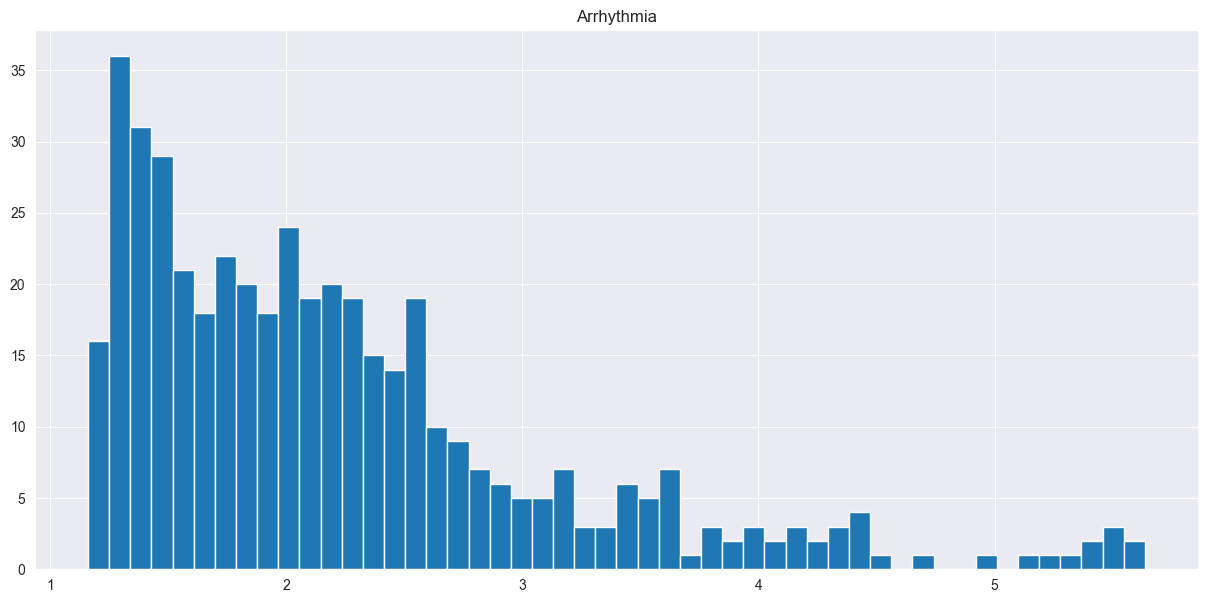

stats: 0.07462062911419498, p-value:0.012628158023852448


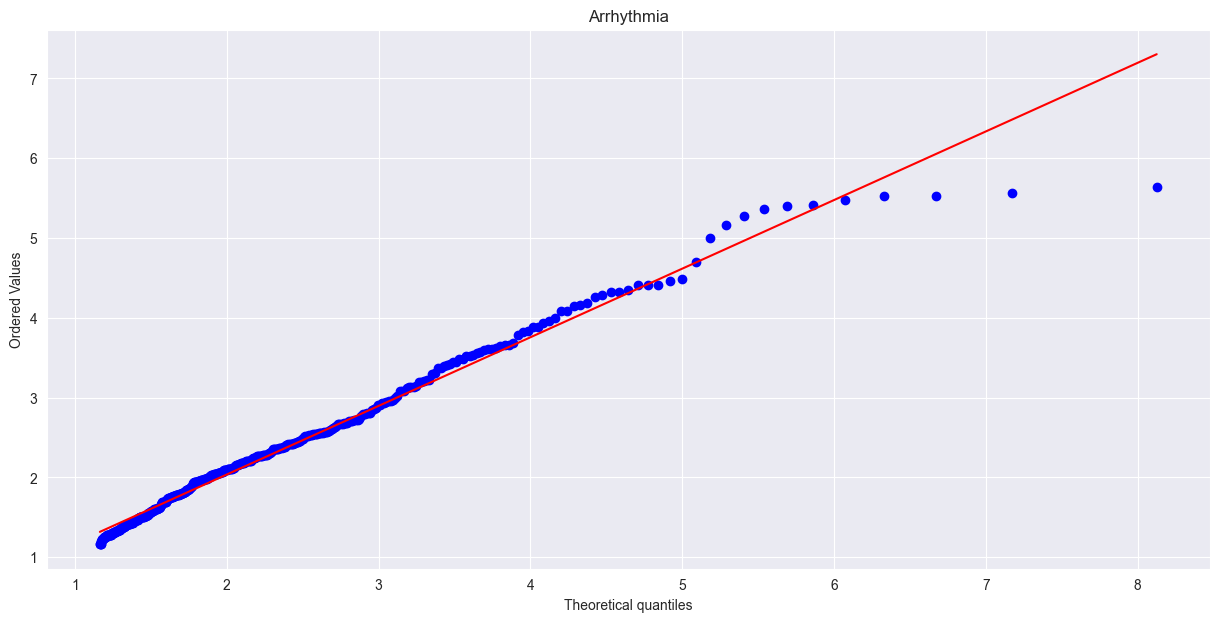

In [24]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2, "Arrhythmia")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Arrhythmia")

1 2 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
2.0166438402863975
[2.03399573 1.47128628 1.06425166 0.76982407 0.55685052 0.40279659
 0.29136201 0.21075606 0.15244993 0.11027432 0.07976668 0.05769905
 0.04173648]
5.014358731170108


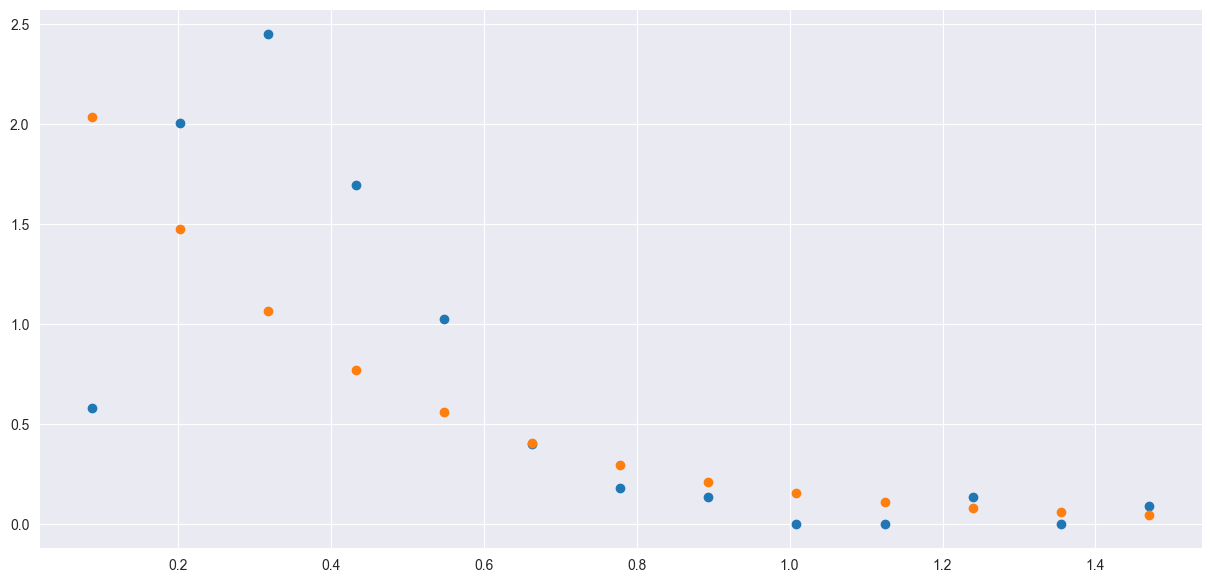

Loc: 0.08760931535152927, scale: 0.35562895291234586
stats: 0.2245288853862027, p-value:4.0549989280904765e-09


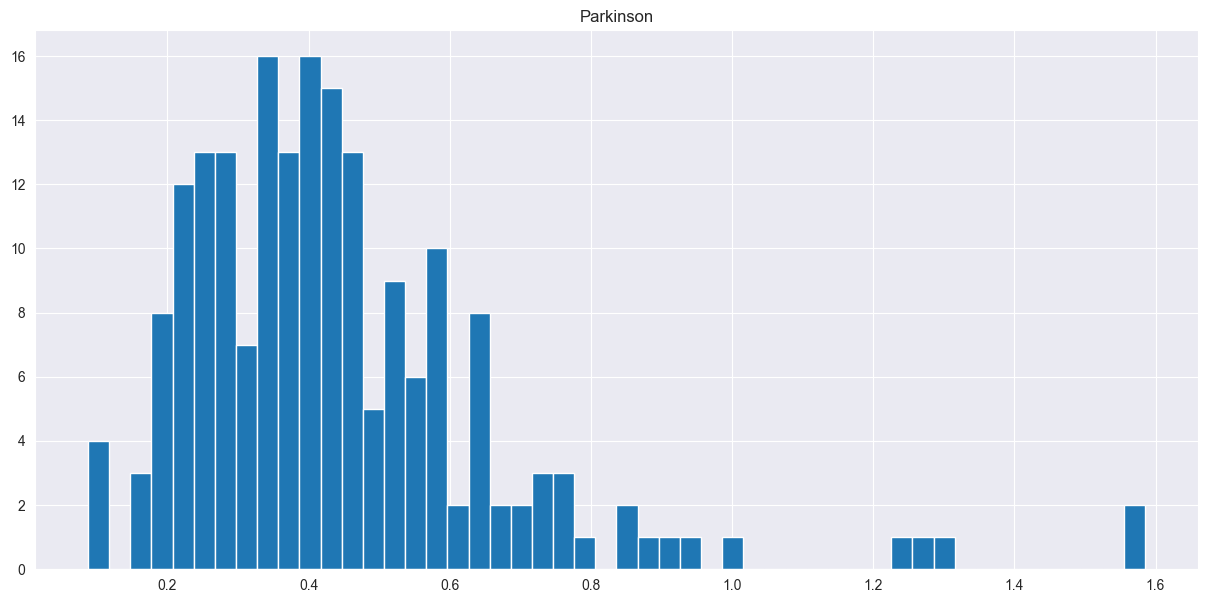

stats: 0.08431480660524138, p-value:0.11799890991298367


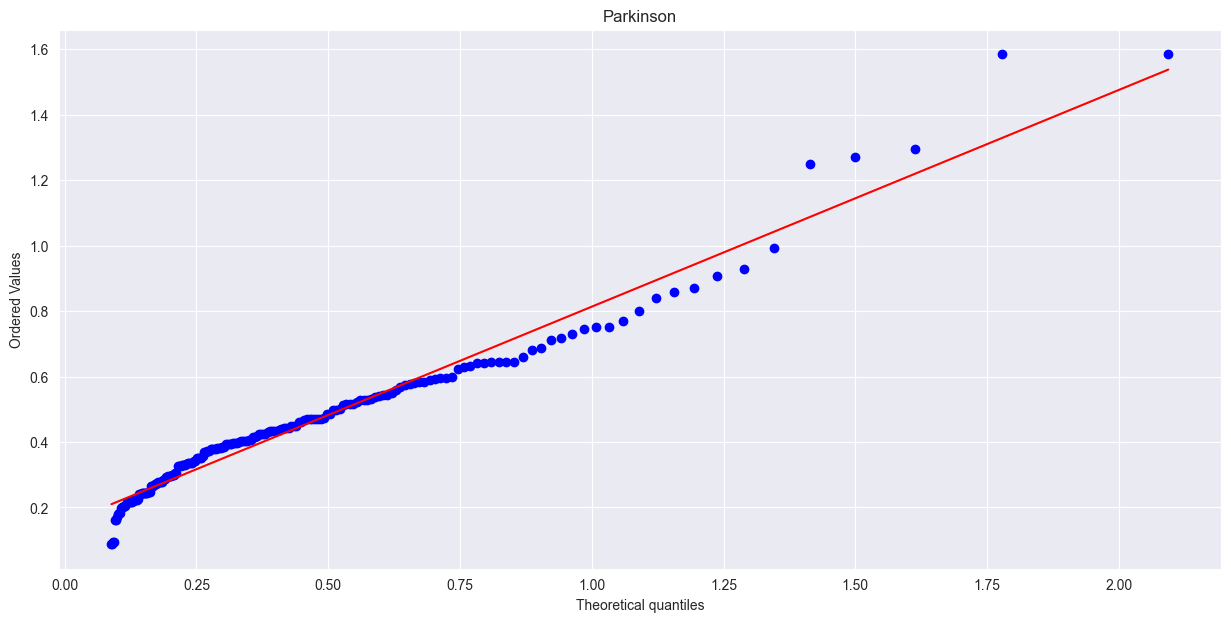

In [25]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2,"Parkinson")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Parkinson")

0.9893617021276596 6 [0.0, 0.9230769230769231, 0.9857142857142855, 0.9318181818181819, 0.9893617021276596, 0.9891304347826088, 0.97, 0.92, 0.9259259259259259, 0.923728813559322, 0.8854166666666665, 0.9687500000000001, 0.9117647058823529, 0.951923076923077, 0.8823529411764707, 0.8928571428571429, 0.8545454545454546, 0.8389830508474577, 0.8362068965517242, 0.7457627118644068, 0.725, 0.725, 0.711864406779661, 0.711864406779661, 0.775, 0.7295081967213115, 0.7377049180327868, 0.7377049180327868, 0.7459016393442623, 0.7416666666666667, 0.7416666666666667, 0.7540983606557377, 0.7583333333333333, 0.7580645161290323, 0.7704918032786885, 0.7540983606557377, 0.7622950819672131, 0.7459016393442622, 0.7540983606557377, 0.7542372881355932, 0.7033898305084745, 0.7, 0.6916666666666667, 0.7166666666666667, 0.721311475409836, 0.7540983606557377, 0.7540983606557377, 0.7499999999999999, 0.7916666666666666, 0.7950819672131147, 0.819672131147541, 0.8064516129032258, 0.814516129032258, 0.819672131147541, 0.8

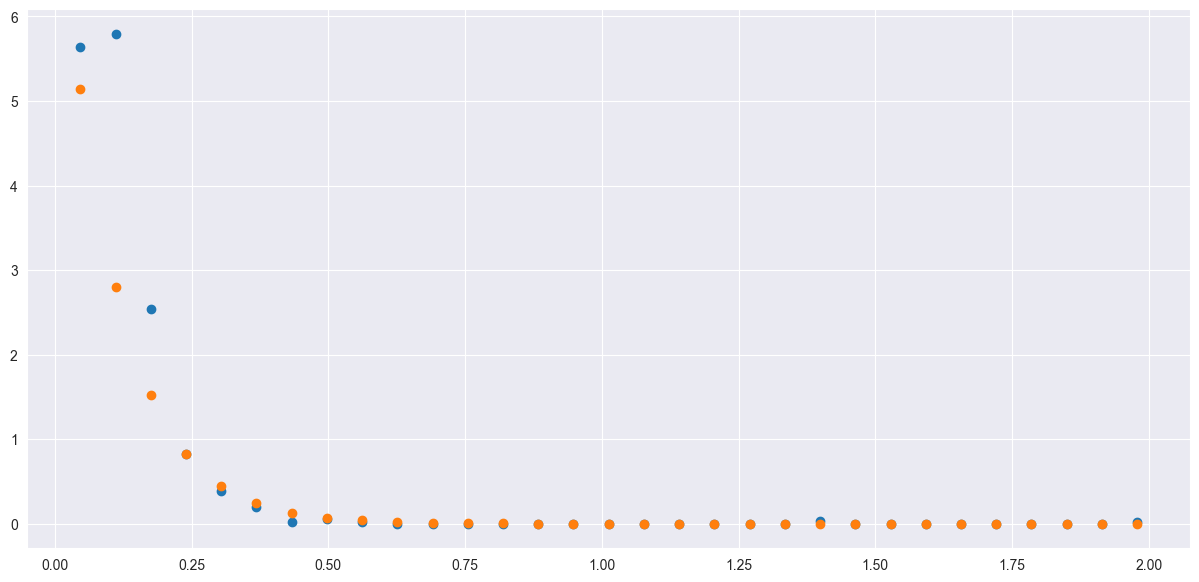

Loc: 0.046603209729096026, scale: 0.10560690329614054
stats: 0.14549924883621887, p-value:3.5239316278374557e-19


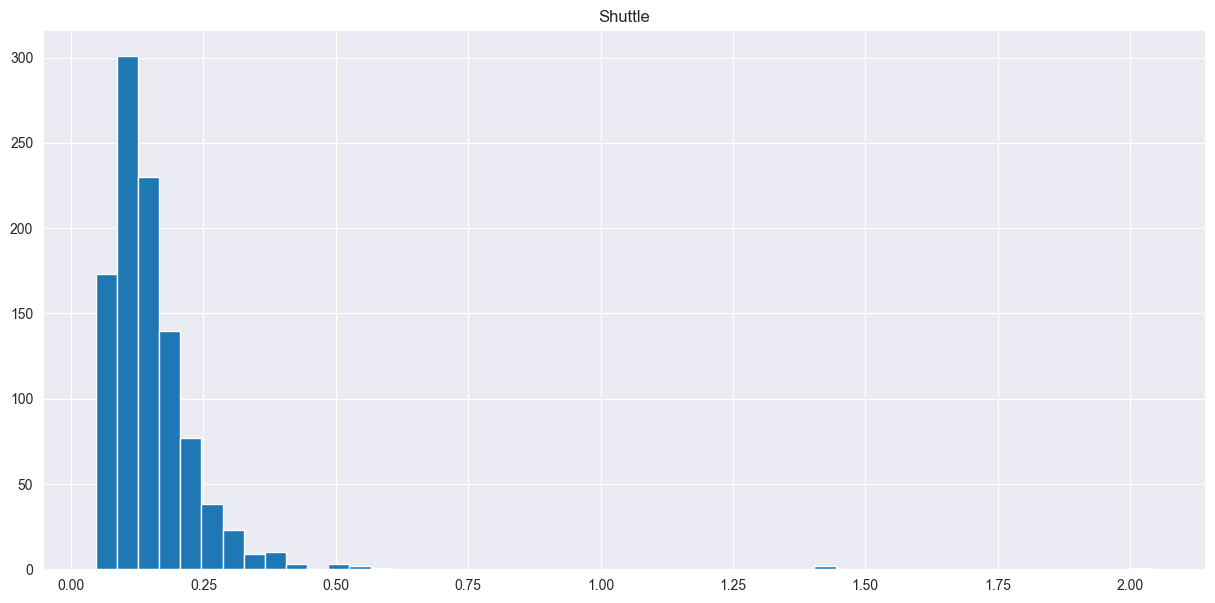

stats: 0.15062084756601357, p-value:1.5781261505498467e-20


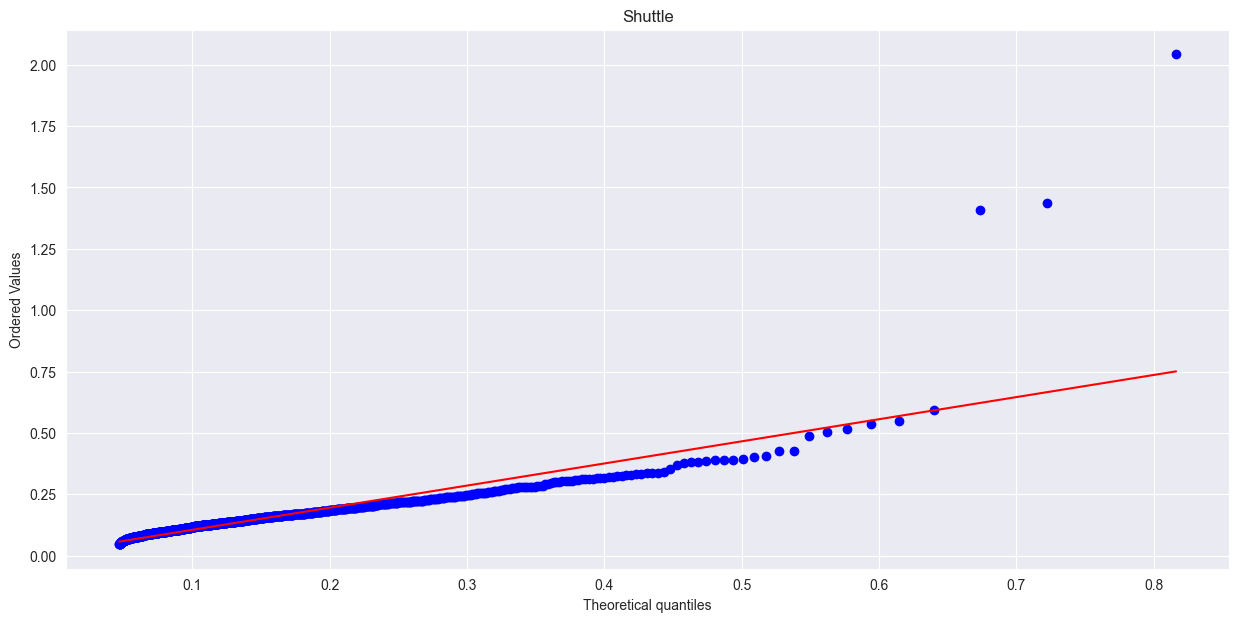

In [26]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,6)
ksTestArr(X,y,6,"Shuttle")
ksTestNorm(X,y,6)
qqPlots(X,y,6,"Shuttle")

0.8235294117647058 32 [0.4523809523809525, 0.6838235294117647, 0.6477272727272727, 0.5789473684210527, 0.6447368421052632, 0.7105263157894738, 0.7368421052631581, 0.631578947368421, 0.5394736842105263, 0.5657894736842105, 0.5789473684210525, 0.6052631578947368, 0.7236842105263158, 0.7236842105263158, 0.7499999999999999, 0.7631578947368421, 0.7763157894736842, 0.6052631578947368, 0.6052631578947368, 0.6111111111111112, 0.6111111111111112, 0.631578947368421, 0.6578947368421053, 0.638888888888889, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6944444444444444, 0.6666666666666666, 0.6111111111111112, 0.8235294117647058, 0.6470588235294117, 0.676470588235294, 0.676470588235294, 0.676470588235294, 0.7058823529411764, 0.6666666666666666, 0.6666666666666666, 0.6944444444444444, 0.6944444444444444, 0.7222222222222222, 0.7222222222222222, 0.75, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.7222222222222222, 0.6944444444444444, 0.694444444444444

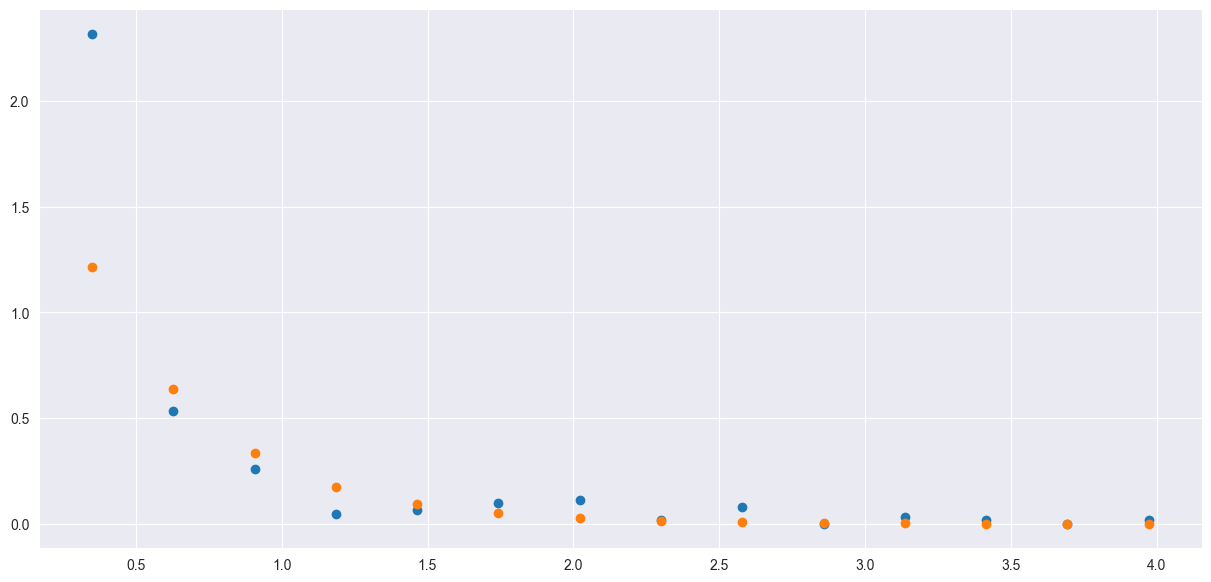

Loc: 0.3495849299935525, scale: 0.43311321660490854
stats: 0.19311674992469952, p-value:9.269673781374634e-08


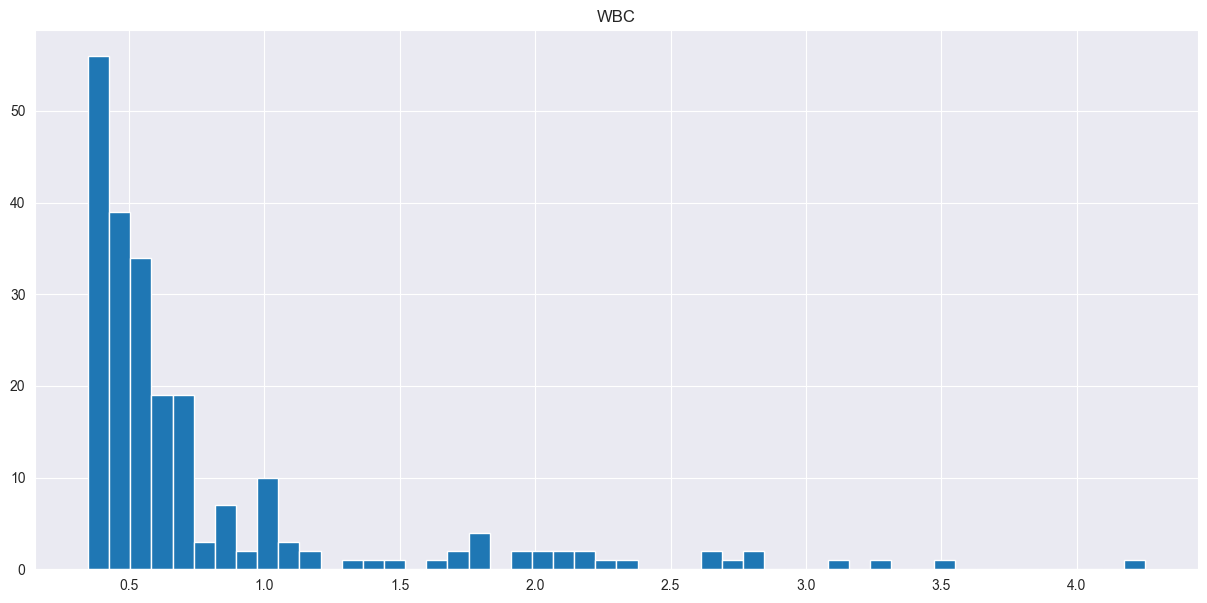

stats: 0.37922470962739846, p-value:2.481348921917112e-29


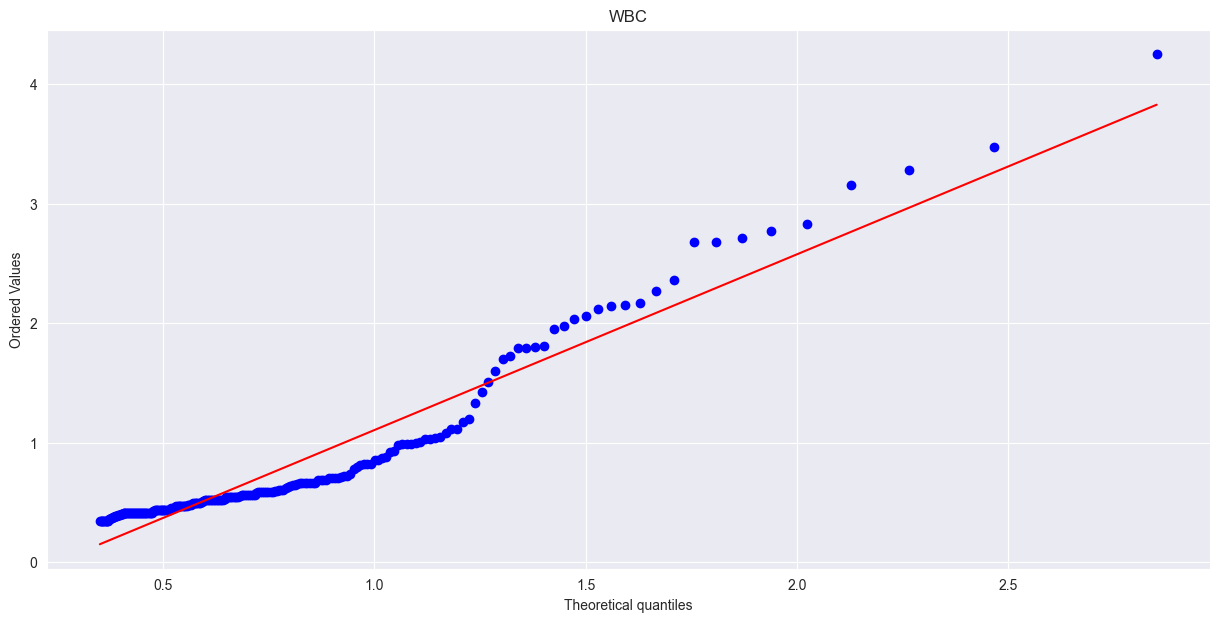

In [27]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,32)
ksTestArr(X,y,32,"WBC")
ksTestNorm(X,y,32)
qqPlots(X,y,32,"WBC")

0.558103354978355 20 [0.4704927327079682, 0.460759493670886, 0.4912457912457912, 0.5029905682079595, 0.49428295908527353, 0.47450680744651297, 0.45343353964043615, 0.4837728194726166, 0.4636699507389162, 0.5110110110110109, 0.4955387205387205, 0.5212662337662338, 0.5413473818646232, 0.5457423235201012, 0.5515094926859633, 0.5560782556750299, 0.5556640625, 0.5528041294642858, 0.558103354978355, 0.5424274973147153, 0.5085851648351648, 0.5068993506493507, 0.501082251082251, 0.499800106609808, 0.4867768595041322, 0.48341909662664373, 0.4877296211251435, 0.4987024221453286, 0.4804647785039941, 0.47694955844933395, 0.49291044776119397, 0.4751975417032484, 0.4924901740595171, 0.5004773595199127, 0.49902656097900155, 0.49089635854341734, 0.48543417366946773, 0.4841036414565826, 0.48491169517452365, 0.4901960784313725, 0.4947101142615319, 0.5017142857142857, 0.494047619047619, 0.4833104395604395, 0.481043956043956, 0.4866694879390605, 0.48427140640428834, 0.4871412333049162, 0.49033920137398024

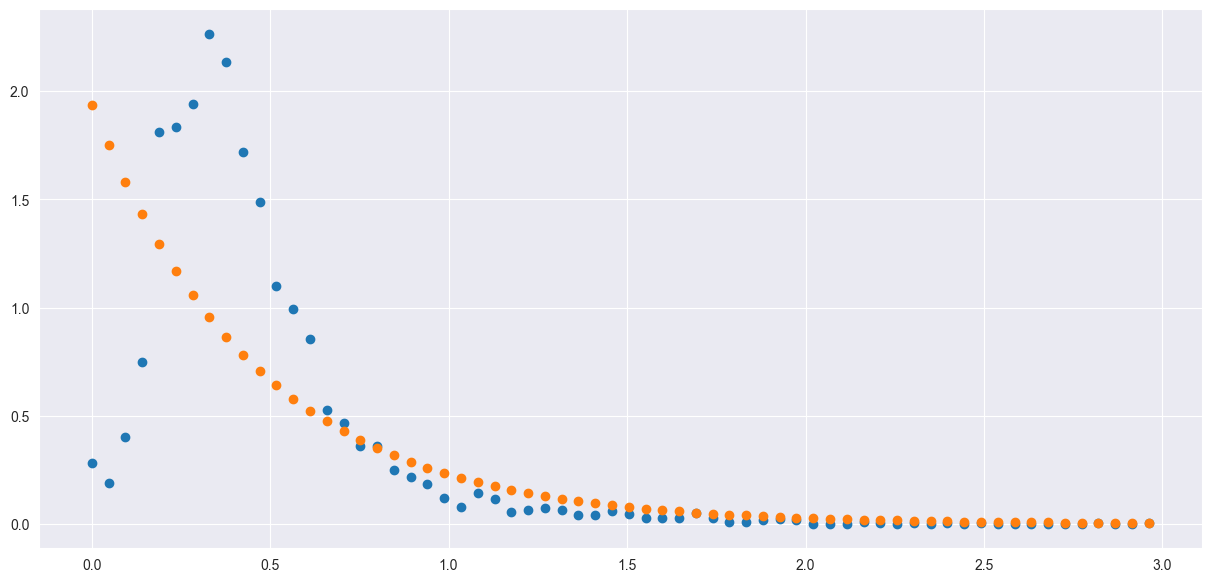

Loc: 0.0007857768723420264, scale: 0.46756615281800323
stats: 0.2558564441411734, p-value:2.6376489475045234e-243


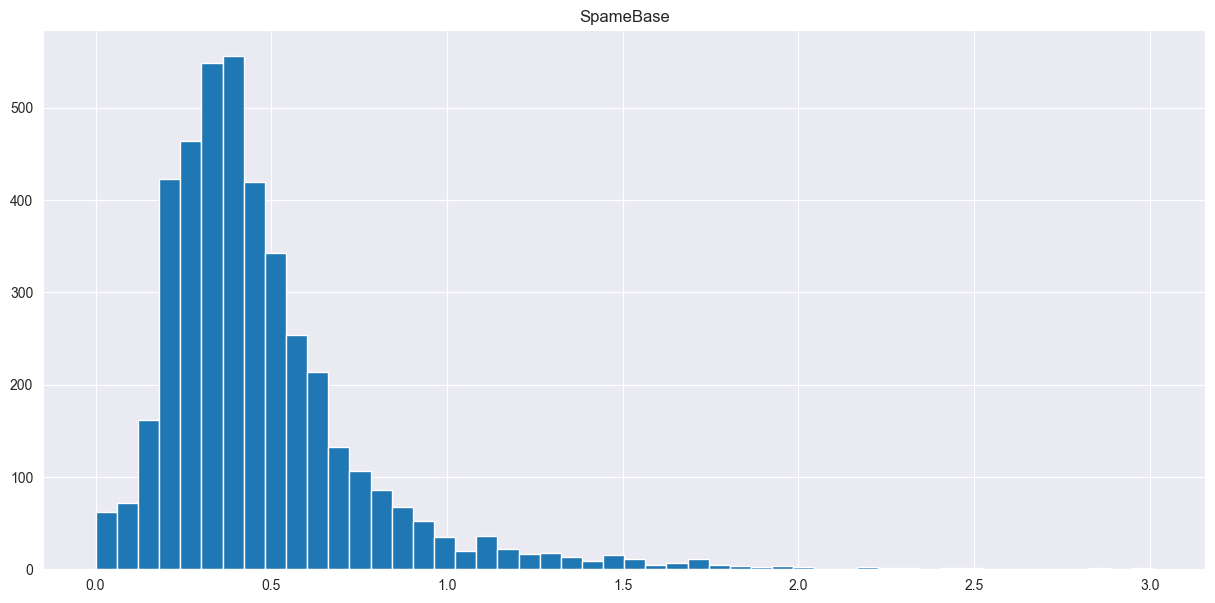

stats: 0.09343820966847116, p-value:2.0421695458097158e-32


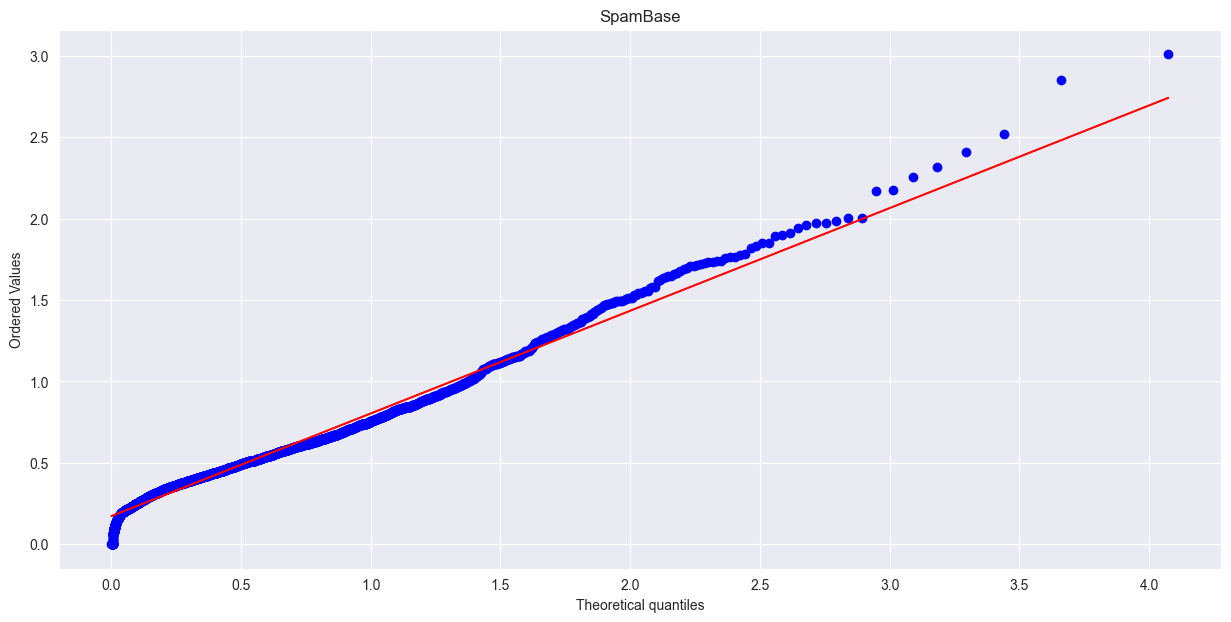

In [28]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,20)
ksTestArr(X,y,20,"SpameBase")
ksTestNorm(X,y,20)
qqPlots(X,y,20,"SpamBase")

0.548076923076923 42 [0.25, 0.38888888888888884, 0.275, 0.5, 0.37499999999999994, 0.34090909090909083, 0.45833333333333337, 0.3636363636363636, 0.4375, 0.49999999999999994, 0.5192307692307692, 0.380952380952381, 0.375, 0.4027777777777778, 0.41666666666666663, 0.39423076923076916, 0.43269230769230765, 0.4553571428571428, 0.46428571428571414, 0.34615384615384615, 0.2916666666666667, 0.3854166666666666, 0.43269230769230765, 0.4326923076923076, 0.43269230769230765, 0.38541666666666663, 0.38541666666666663, 0.43749999999999994, 0.39583333333333326, 0.4166666666666666, 0.4374999999999999, 0.4903846153846153, 0.49999999999999994, 0.4903846153846153, 0.4903846153846153, 0.42708333333333326, 0.5192307692307692, 0.48958333333333326, 0.4791666666666666, 0.5288461538461537, 0.548076923076923, 0.43181818181818177, 0.4431818181818181, 0.48958333333333326, 0.4431818181818181, 0.4431818181818181, 0.4431818181818181, 0.3749999999999999, 0.3749999999999999, 0.3999999999999999, 0.34090909090909083, 0.363

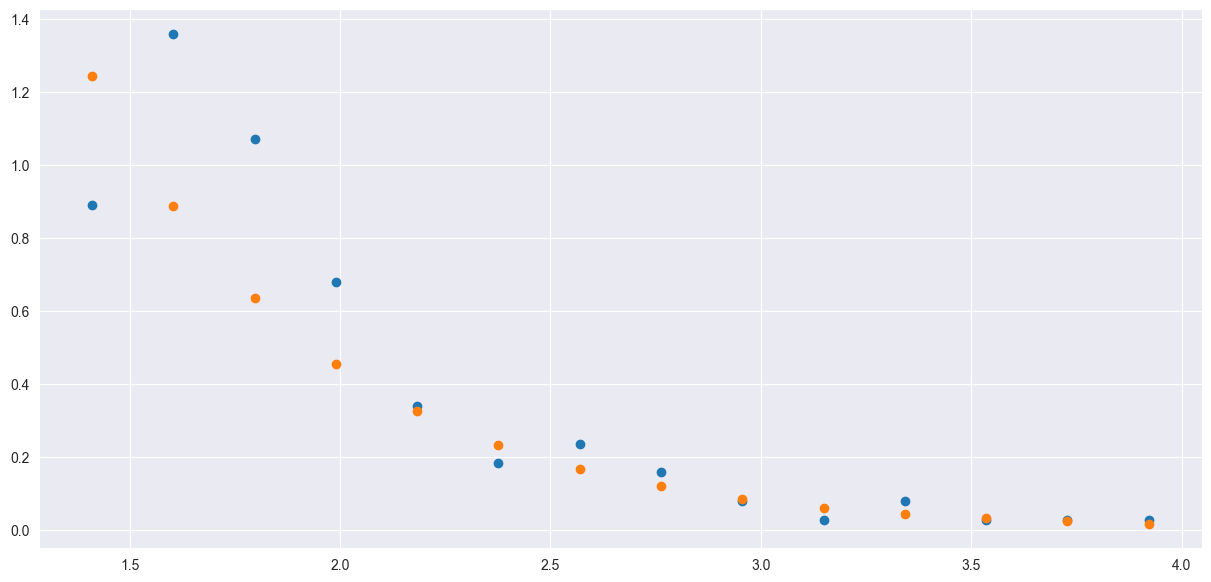

Loc: 1.4102418514497834, scale: 0.5745033667775841
stats: 0.13713041700021095, p-value:0.001040107284370563


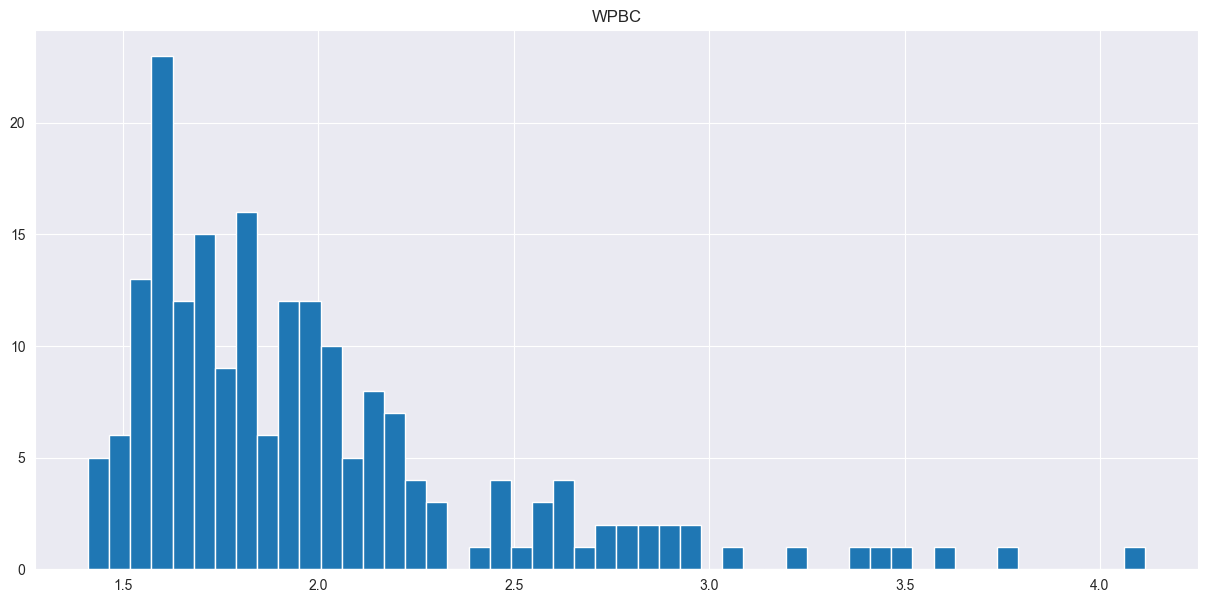

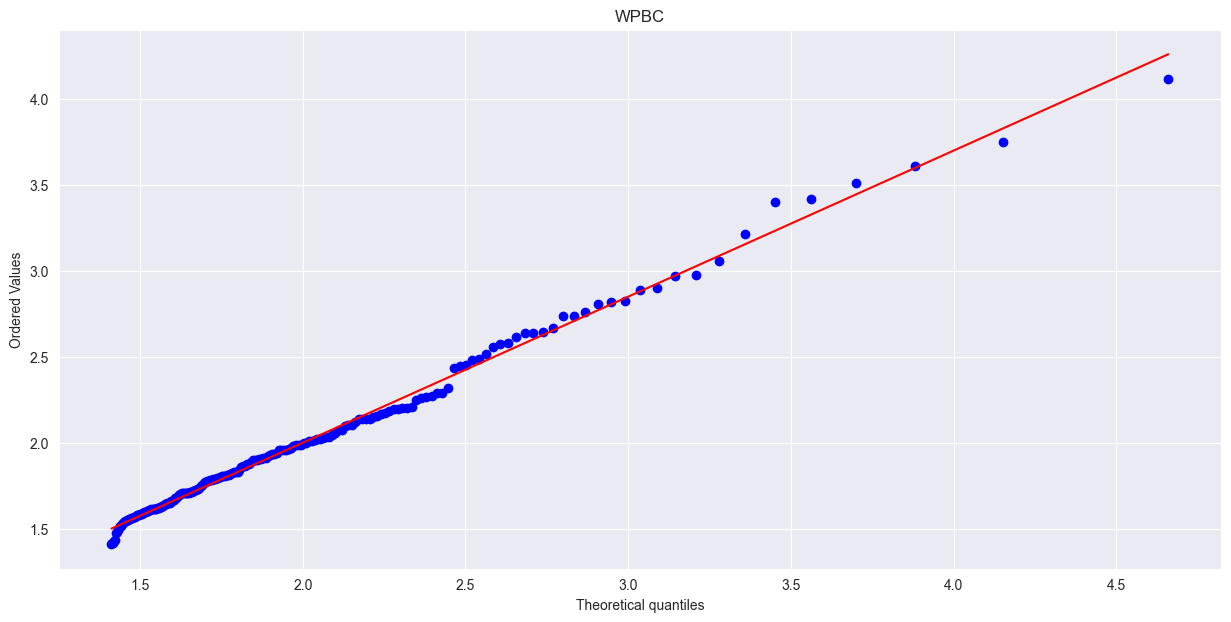

In [29]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 42)
ksTestArr(X,y,42,"WPBC")
qqPlots(X,y,42,"WPBC")

1.0 5 [0.42857142857142855, 0.6666666666666666, 0.7000000000000001, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8, 0.8500000000000001, 0.8, 0.8500000000000001, 0.7000000000000001, 0.875, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8333333333333333, 0.8333333333333331, 0.8333333333333331, 0.8166666666666665, 0.9800000000000001, 1.0, 1.0, 1.0]
0.5804803424580274
[0.96050791 0.81585551 0.69298775 0.58862387 0.49997717 0.42468066
 0.36072379 0.30639882 0.26025519 0.22106078 0.18776905 0.15949105
 0.13547171 0.11506969 0.0977402  0.08302054]
2.908013452211466


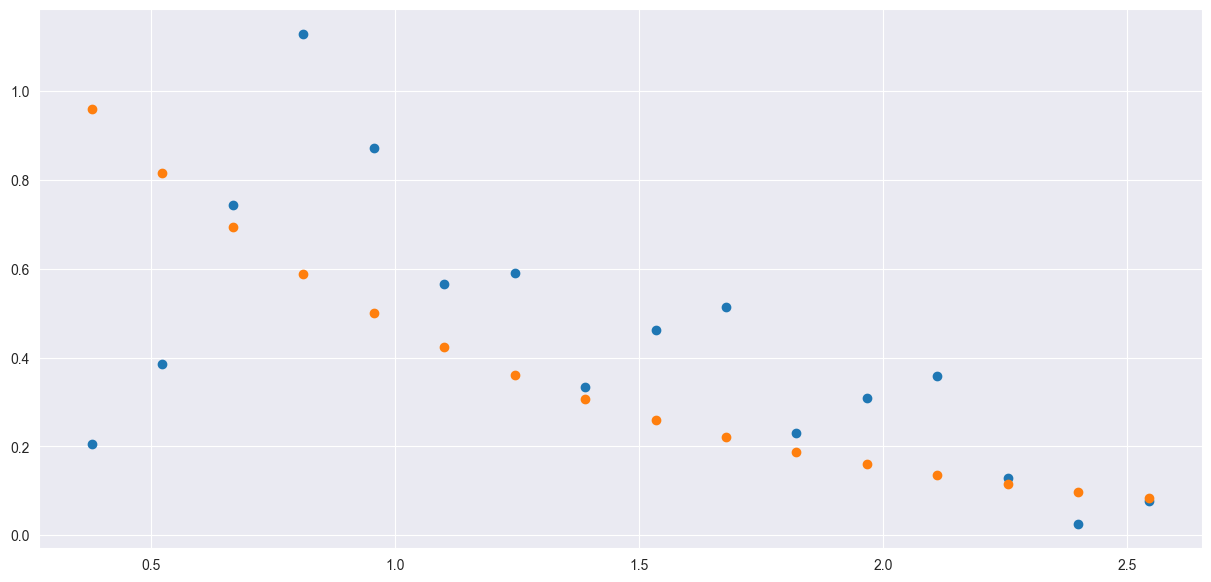

Loc: 0.378757995940565, scale: 0.8843238956869015
stats: 0.21750524751226377, p-value:1.0767017063527005e-11


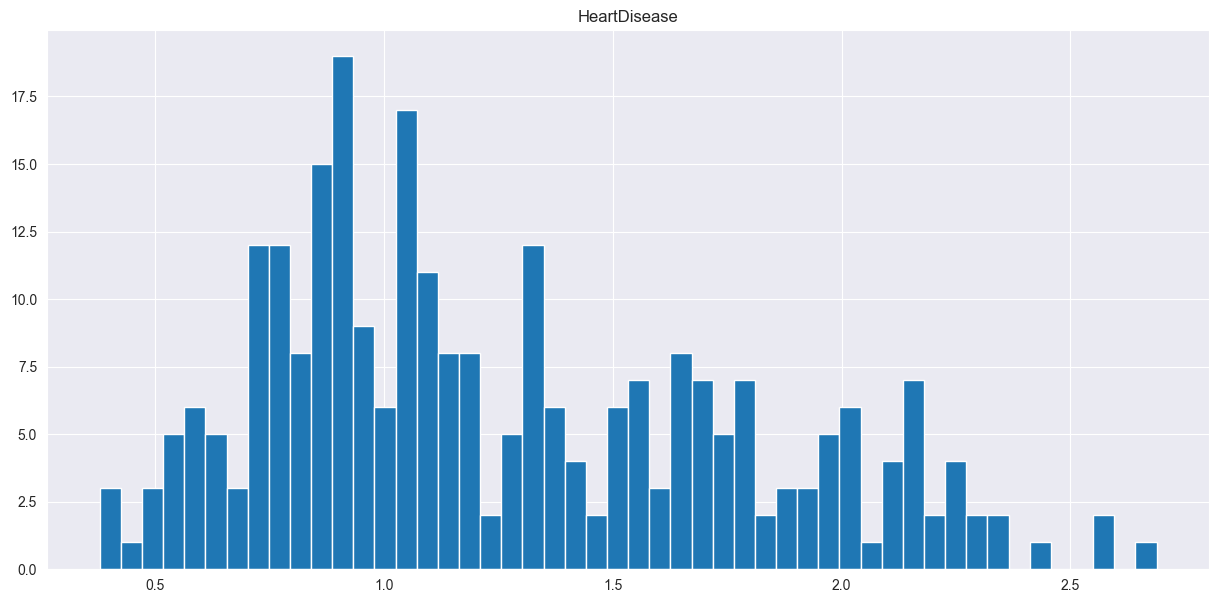

stats: 0.04952021226563741, p-value:0.5062174254912717


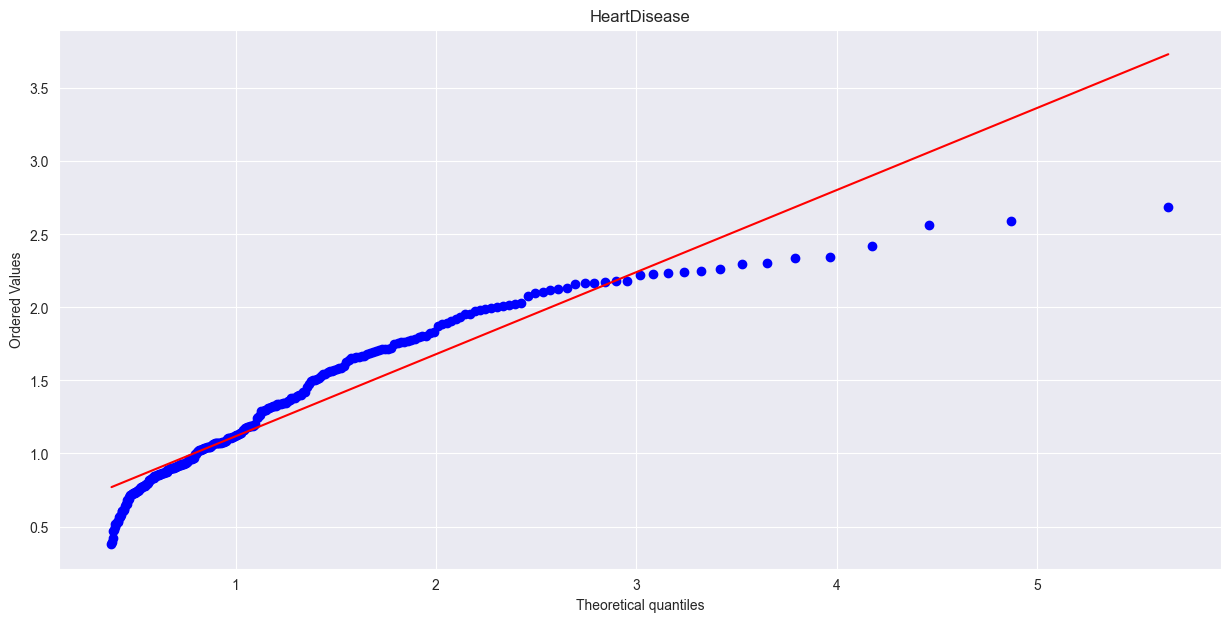

In [30]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 5)
ksTestArr(X,y,5,"HeartDisease")
ksTestNorm(X,y,5)
qqPlots(X,y,5,"HeartDisease")

0.8881578947368421 63 [0.31666666666666665, 0.36718749999999994, 0.4407894736842105, 0.65, 0.638888888888889, 0.6323529411764706, 0.638888888888889, 0.631578947368421, 0.5833333333333334, 0.5277777777777779, 0.47058823529411775, 0.47058823529411775, 0.5, 0.5138888888888888, 0.5263157894736843, 0.5, 0.47058823529411775, 0.5263157894736843, 0.5, 0.5, 0.5125, 0.4736842105263158, 0.4625, 0.43421052631578955, 0.4523809523809524, 0.4210526315789474, 0.3611111111111111, 0.3289473684210526, 0.33333333333333326, 0.26315789473684215, 0.23611111111111105, 0.4722222222222221, 0.46296296296296285, 0.6805555555555555, 0.6805555555555555, 0.6805555555555555, 0.6805555555555555, 0.6617647058823529, 0.6805555555555555, 0.6617647058823529, 0.6617647058823529, 0.6805555555555554, 0.6944444444444444, 0.6973684210526316, 0.6944444444444444, 0.8020833333333333, 0.79, 0.8076923076923077, 0.8333333333333333, 0.8392857142857143, 0.8392857142857143, 0.853448275862069, 0.8548387096774193, 0.8548387096774193, 0.8

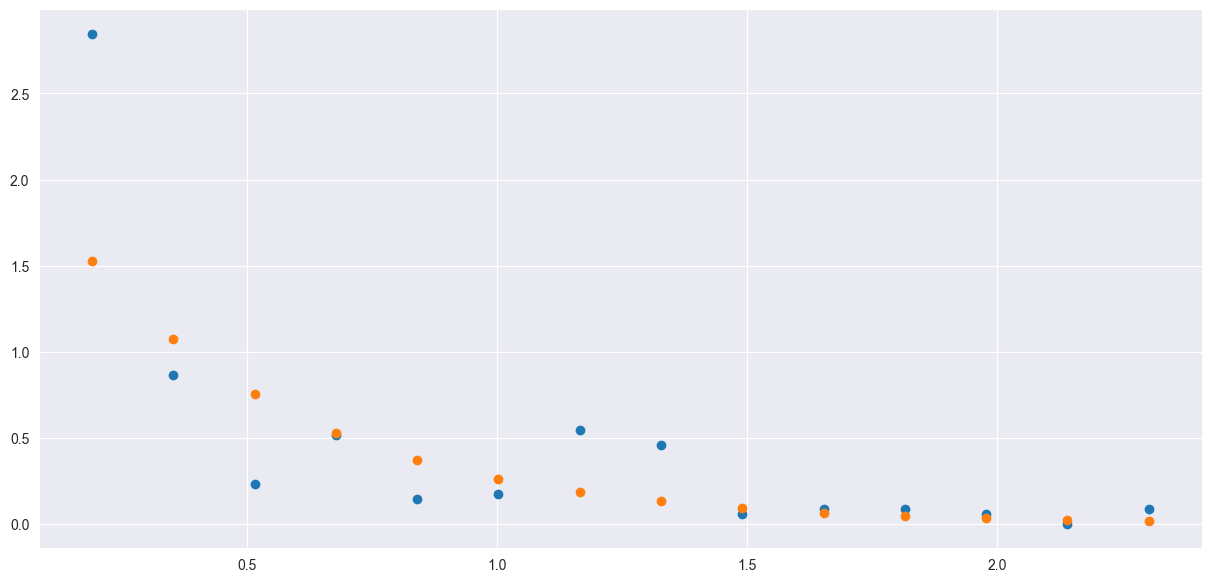

Loc: 0.190605325813865, scale: 0.46138693055342717
stats: 0.18995453005135088, p-value:3.095426487819056e-07


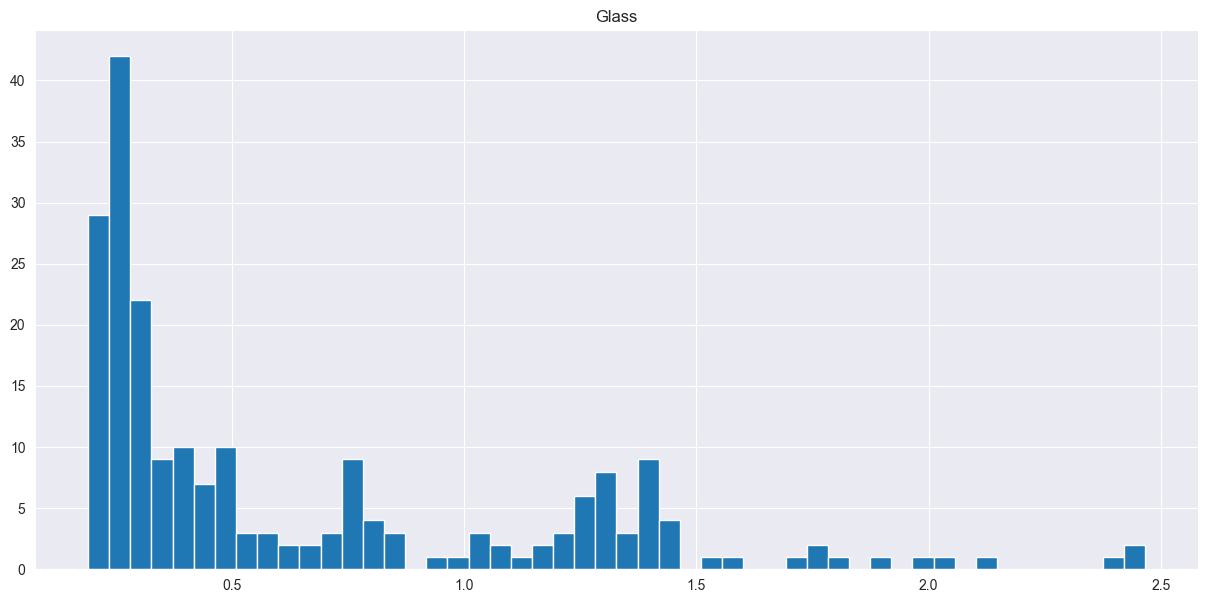

stats: 0.29300831234136077, p-value:8.989238314095667e-17


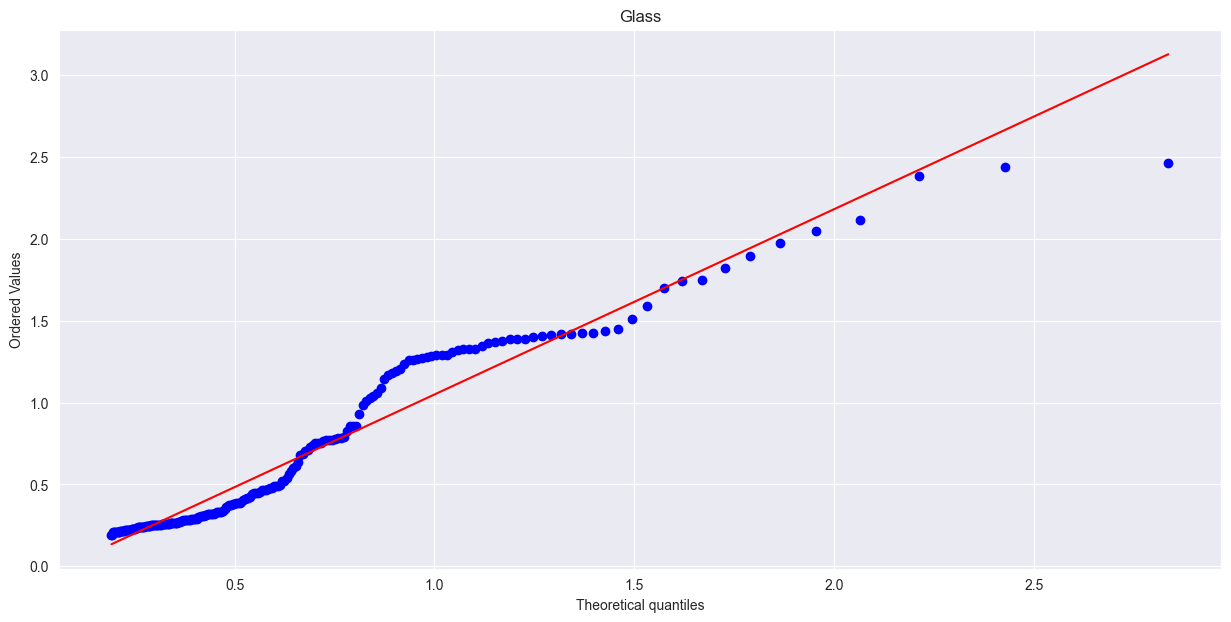

In [31]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 63)
ksTestArr(X,y,63,"Glass")
ksTestNorm(X,y,63)
qqPlots(X,y,63,"Glass")

1.0 2 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.33333333333333326, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.25, 0.0, 0.0, 0.0, 0.0, 0.0]
-0.4814067501859048
[0.57773822 0.45743981 0.36219031 0.28677395 0.22706101 0.17978168
 0.14234699 0.11270707]
5.035550989210265


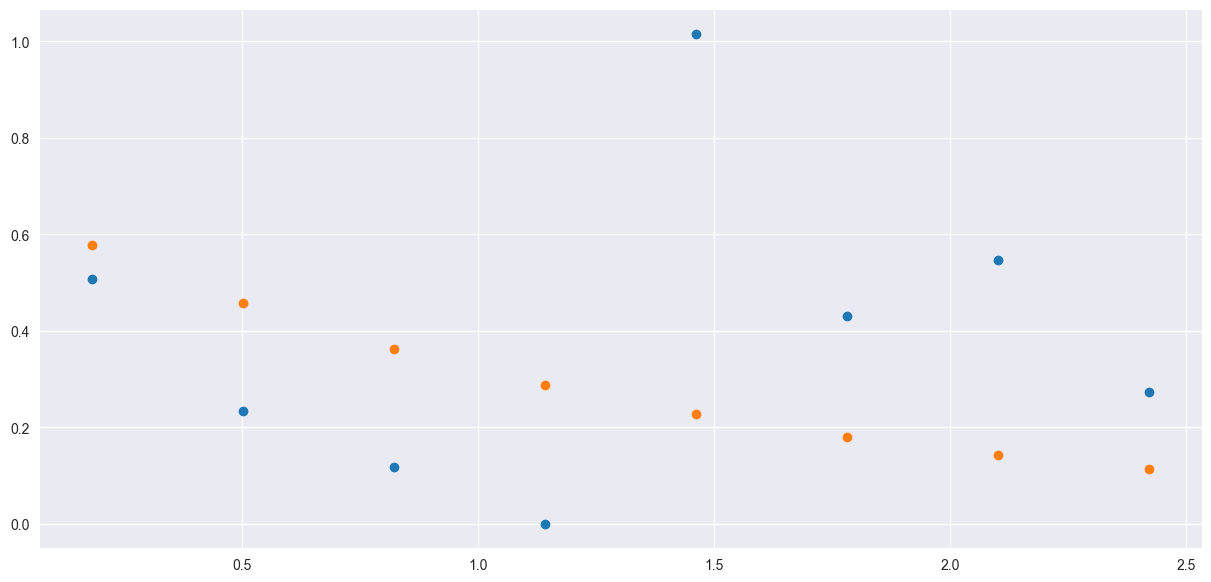

Loc: 0.18180961633193196, scale: 1.370477056647892
stats: 0.3521249349385399, p-value:2.2414969393625678e-09


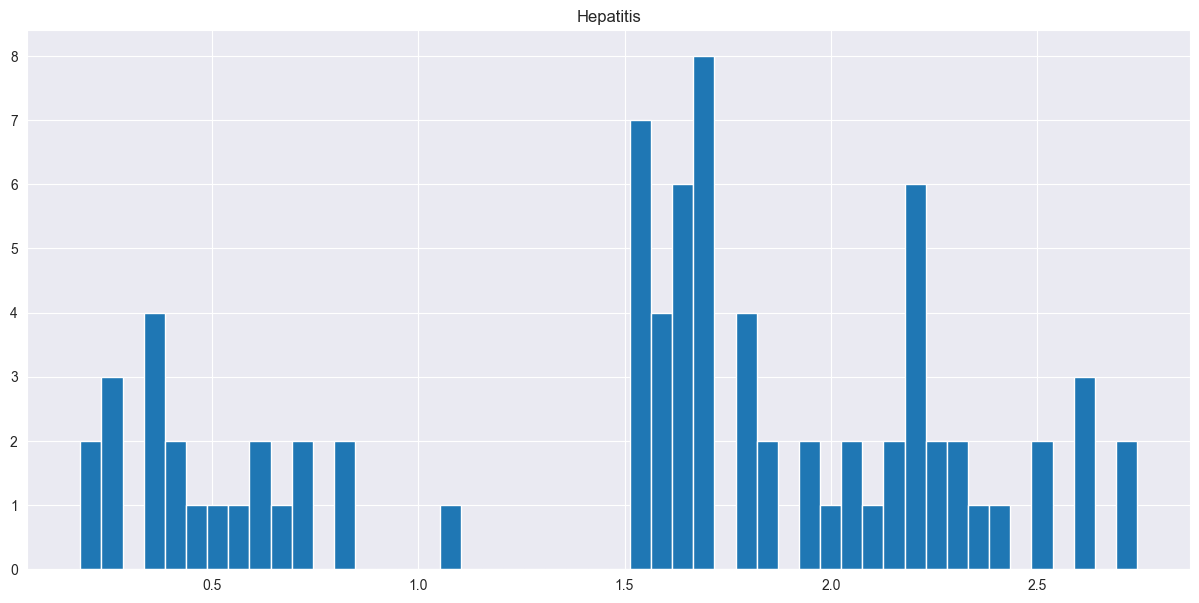

stats: 0.15088822680669356, p-value:0.04692520045010018


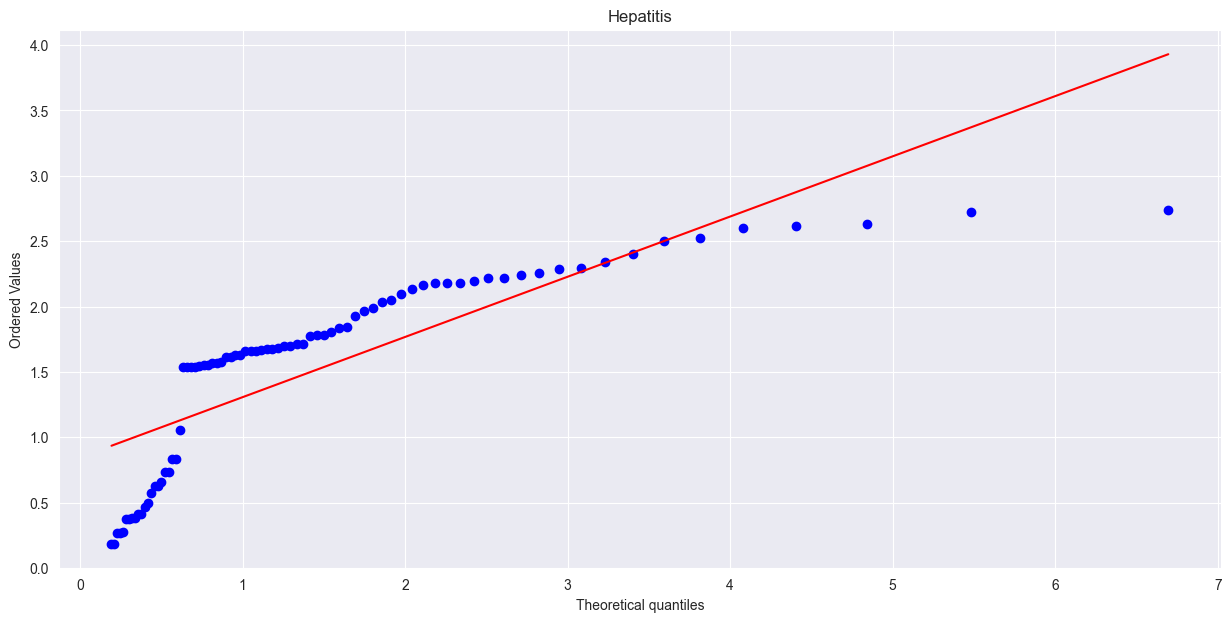

In [32]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 2)
ksTestArr(X,y,2,"Hepatitis")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Hepatitis")

0.6714285714285714 2 [0.6714285714285714, 0.6428571428571428, 0.6092436974789914, 0.5249999999999999, 0.5491452991452992, 0.6052631578947368, 0.5925925925925926, 0.5954861111111112, 0.5515873015873015, 0.5814814814814815, 0.632716049382716, 0.6140350877192983, 0.5862573099415205, 0.5648148148148149, 0.5332409972299169, 0.5062500000000001, 0.53, 0.6161764705882354, 0.5743034055727555, 0.5277777777777779, 0.4833333333333332, 0.4922839506172839, 0.4795321637426899, 0.45277777777777767, 0.41456582633053213, 0.45238095238095233, 0.44179894179894175, 0.48148148148148145, 0.45833333333333326, 0.45959595959595956, 0.46875, 0.48495370370370366, 0.4768518518518518, 0.4768518518518518, 0.480324074074074, 0.4814814814814814, 0.49451754385964913, 0.49890350877192985, 0.5098684210526316, 0.4942129629629629, 0.47800925925925924, 0.48495370370370366, 0.48148148148148145, 0.506578947368421, 0.4936842105263158, 0.48947368421052634, 0.5270833333333333, 0.499, 0.504, 0.48315789473684206, 0.488421052631578

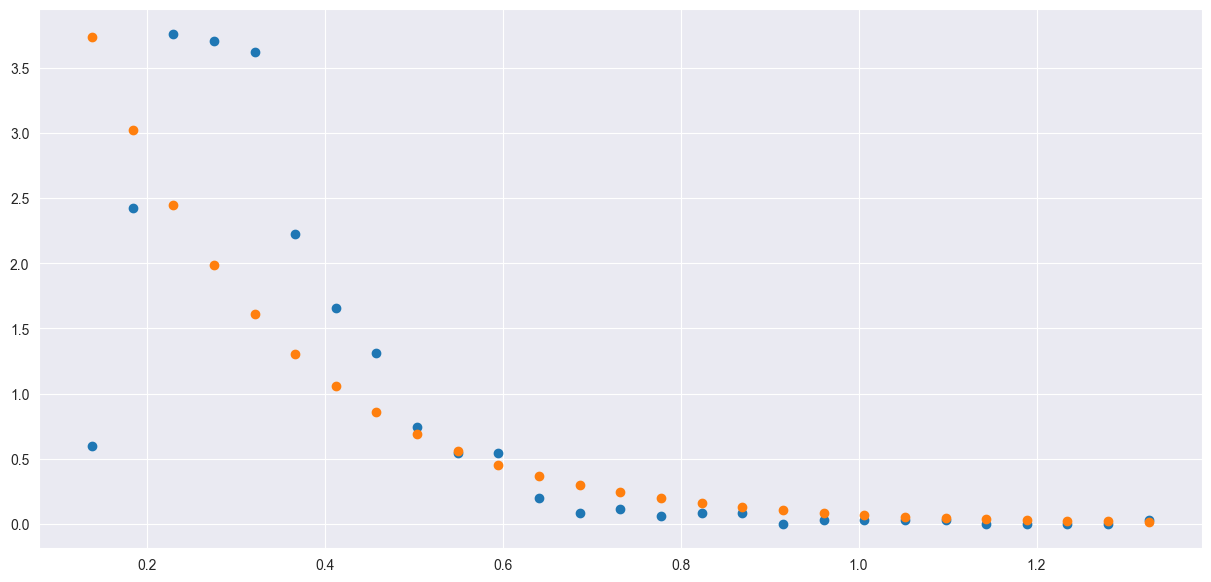

Loc: 0.13840441052224262, scale: 0.21684105970989703
stats: 0.2092573773614875, p-value:5.582453072235402e-30


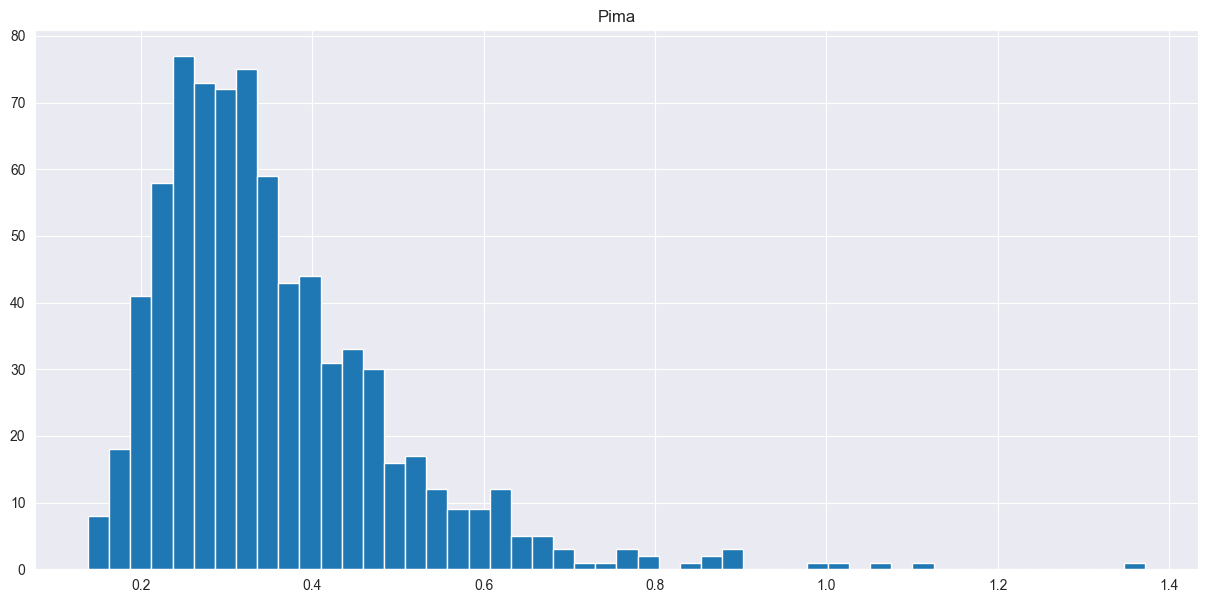

stats: 0.06330663781614843, p-value:0.004051421712574387


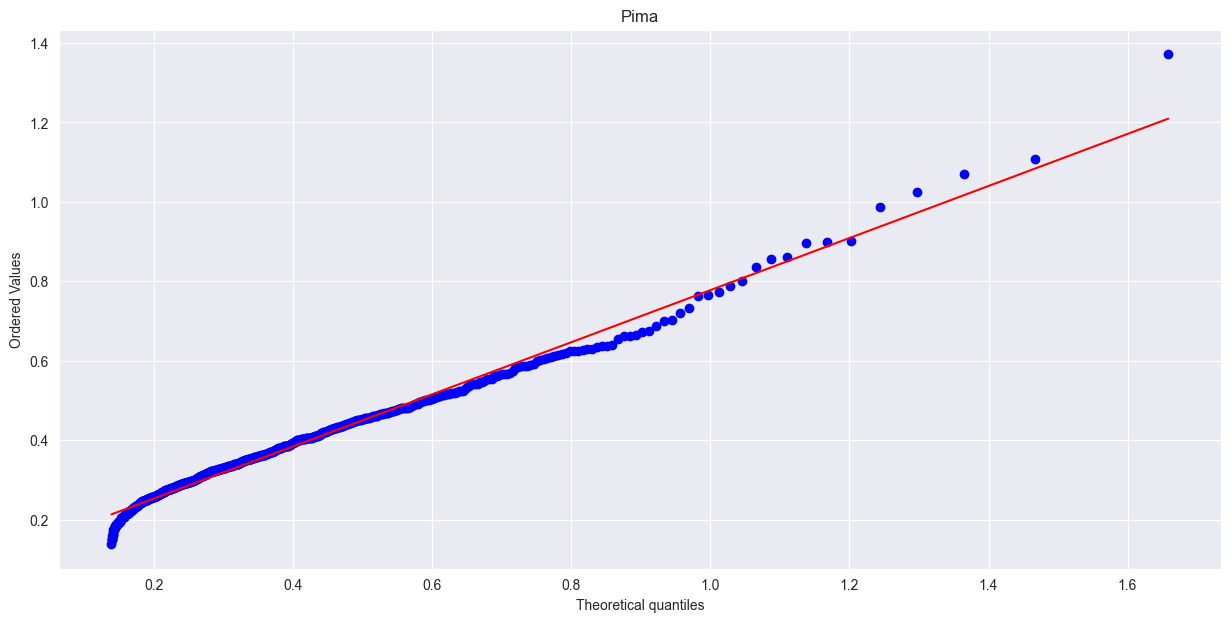

In [33]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)
ksTestArr(X,y,3,"Pima")
ksTestNorm(X,y,3)
qqPlots(X,y,3,"Pima")

0.8580927835051546 20 [0.6672494172494172, 0.5762925598991173, 0.5483058608058609, 0.6599144951140065, 0.6466655237442139, 0.6708850931677017, 0.6991590214067278, 0.7516901408450704, 0.7885117493472584, 0.7960256410256411, 0.8212804878048781, 0.828095238095238, 0.8300000000000001, 0.8235781990521328, 0.8329676674364896, 0.8501075268817203, 0.8535940803382663, 0.8577442827442828, 0.8580927835051546, 0.8558044806517312, 0.8485386221294363, 0.8531837160751566, 0.8540650406504064, 0.8450592885375493, 0.8529092702169625, 0.8519417475728156, 0.8507797270955165, 0.8371047430830039, 0.8437980769230771, 0.8347408829174664, 0.8372410546139359, 0.8354089219330856, 0.8348148148148149, 0.8298623853211008, 0.8323608617594255, 0.8218297101449274, 0.8224689165186502, 0.8263548951048952, 0.8189380530973452, 0.8089285714285713, 0.8048230088495576, 0.7995080500894454, 0.7902154398563733, 0.7817652329749103, 0.7738918439716311, 0.7718309859154929, 0.7718804159445406, 0.7619210977701544, 0.7734924623115578

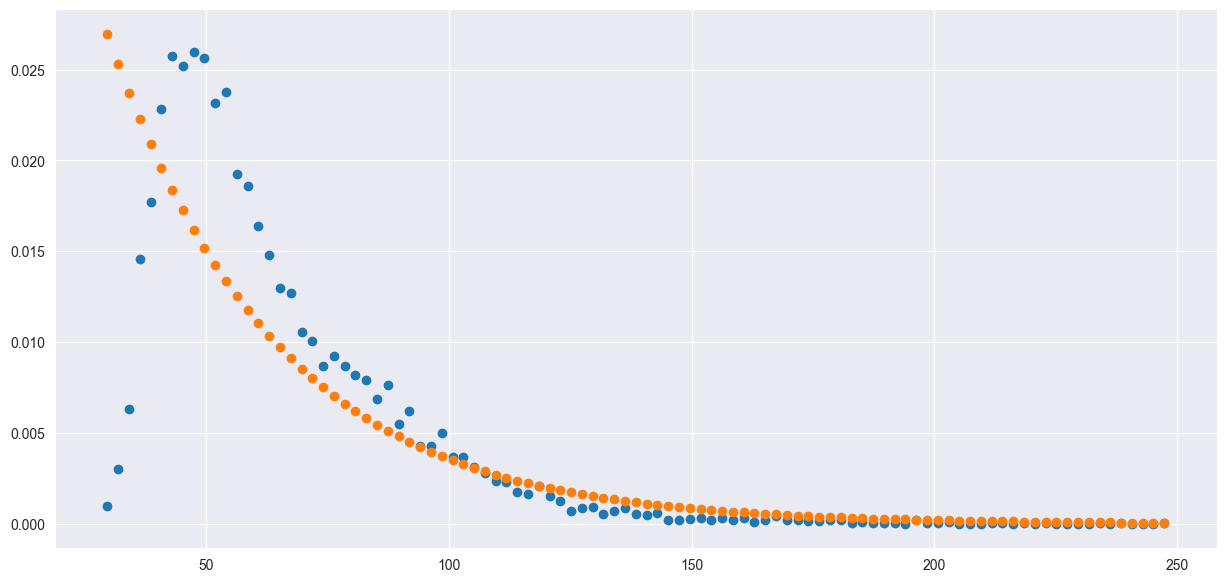

Loc: 29.627164969531574, scale: 34.78829127861681
stats: 0.17996505210740188, p-value:4.181037939901658e-280


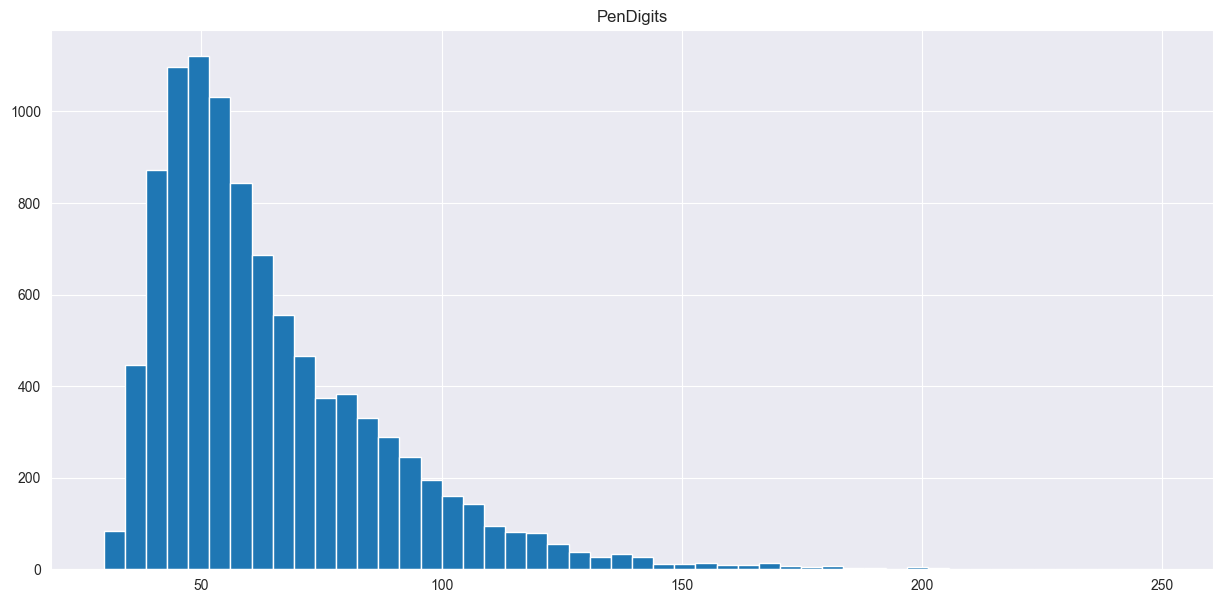

stats: 0.07317360573135961, p-value:2.150088802243422e-46


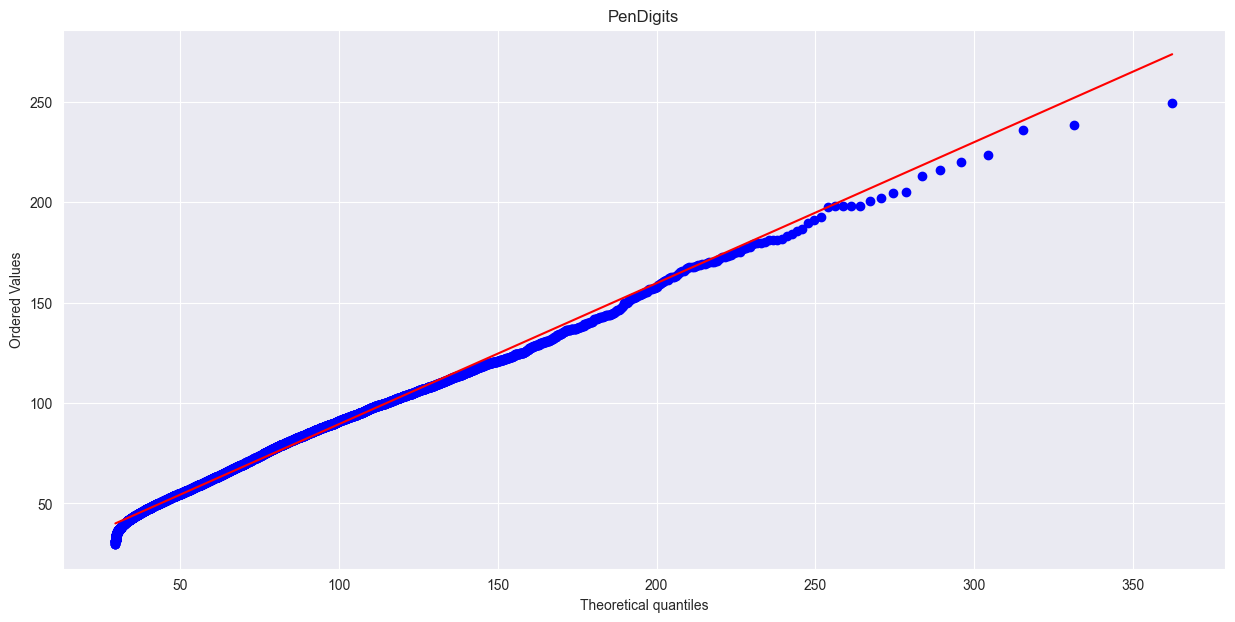

In [34]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 20)
ksTestArr(X,y,20,"PenDigits")
ksTestNorm(X,y,20)
qqPlots(X,y,20,"PenDigits")

0.9172596241561759 55 [0.8135451505016723, 0.8201942067149441, 0.8347264437689971, 0.8612514029180698, 0.858479755538579, 0.8105128205128205, 0.7535133136094675, 0.7880917159763313, 0.7568518518518518, 0.7668566001899336, 0.7834661354581675, 0.758888888888889, 0.6531118747613593, 0.6873601789709172, 0.6810344827586208, 0.6498106060606061, 0.7430481283422459, 0.7280898876404494, 0.767342849987478, 0.7741779497098645, 0.7786082474226804, 0.8008457095709571, 0.8048878205128206, 0.8429432013769362, 0.8436238902340598, 0.8258003766478342, 0.8253012048192769, 0.8334177642688281, 0.8474489795918366, 0.8503597122302158, 0.850795847750865, 0.8445665083135391, 0.8541666666666665, 0.8721291866028709, 0.8693571991444331, 0.8711163770405476, 0.8752632964718273, 0.8863993710691823, 0.8877645502645501, 0.8919239904988123, 0.8787384833451453, 0.8784555288461539, 0.8814948041566747, 0.8976076555023924, 0.9064558629776022, 0.9086266181229773, 0.8968743121285494, 0.8892109728506788, 0.8664522681110358, 0

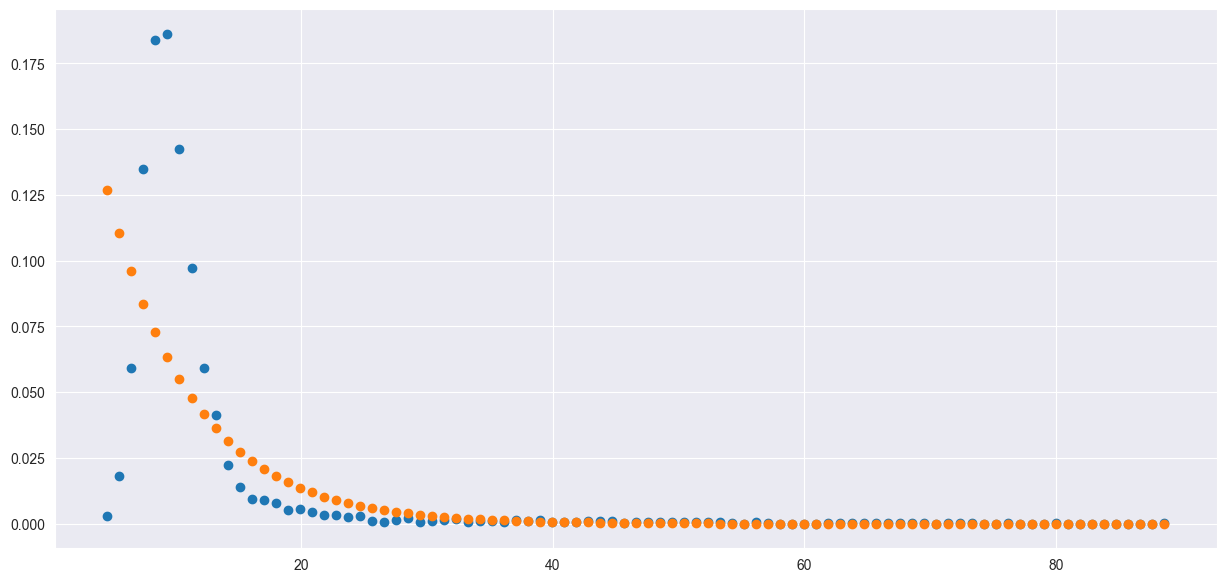

In [35]:
X, y = setupDf("clusters/artificial/cluto-t4-8k.arff")
endResults = outputResultsArt(X, y,checkValue=6)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.907380497131931 28 [0.7192600995777398, 0.7644419725621061, 0.8053696303696303, 0.8185131195335278, 0.7735383447228551, 0.7708576855639977, 0.7838694289219027, 0.8057879344351492, 0.8383244206773617, 0.8047537508153946, 0.7736085053158224, 0.7754901960784313, 0.7606443533697633, 0.8006654567453116, 0.8457010582010582, 0.8544061302681992, 0.8715193295485266, 0.8819646157908636, 0.903640929064658, 0.8954215839613251, 0.8735754041876491, 0.8794810058855004, 0.8807890222984563, 0.8912216895354603, 0.8952123552123553, 0.8961507936507938, 0.907380497131931, 0.8923399057756064, 0.8841423948220065, 0.8853580802399701, 0.8901871574811291, 0.8886353989813243, 0.8844975490196076, 0.8589554682383759, 0.8509020162716661, 0.8676224010731054, 0.864331317204301, 0.8657597535934292, 0.8679471788715487, 0.831848357791754, 0.8467254613751429, 0.8422431865828093, 0.8443446088794926, 0.8407071783937454, 0.8564047892406101, 0.8522899605702153, 0.8491052471944192, 0.8604721549636803, 0.8538734896943851, 0.

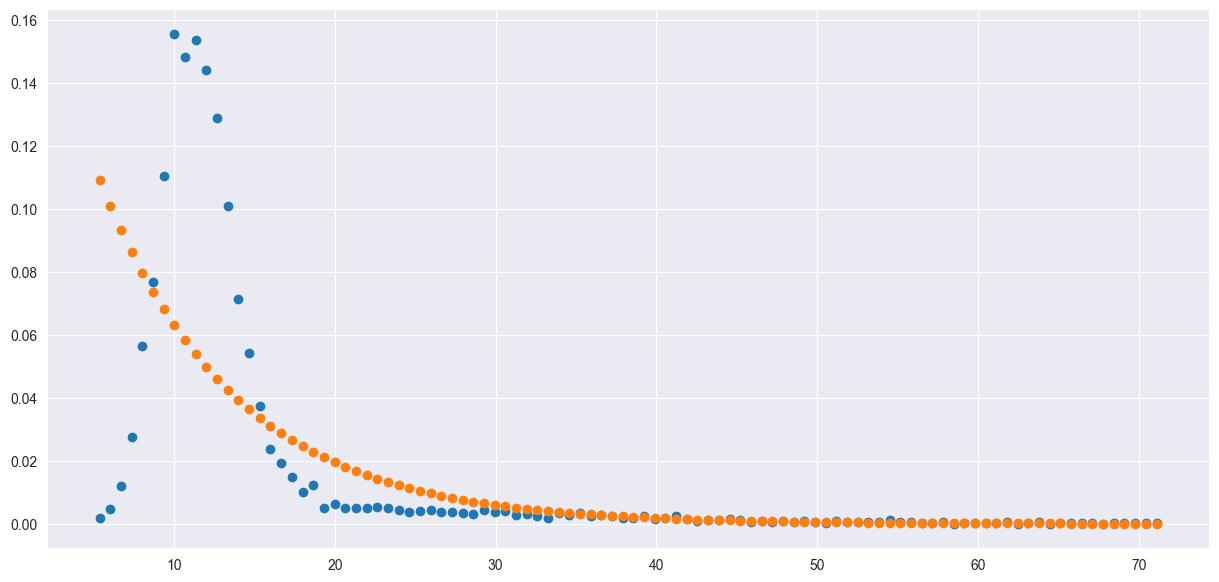

In [36]:
X, y = setupDf("clusters/artificial/cluto-t7-10k.arff")
endResults = outputResultsArt(X, y,checkValue=9)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.8908915795266923 21 [0.7803263403263403, 0.8444074074074074, 0.8550753370340999, 0.8794871794871795, 0.8775075987841944, 0.8403484560979817, 0.841711229946524, 0.8667085164260305, 0.863059849385652, 0.8713913392141139, 0.86293908403735, 0.8485486891385767, 0.8634572959344469, 0.8398268398268398, 0.8678809171597633, 0.8833639705882352, 0.8763840830449827, 0.8561390532544377, 0.8583676268861453, 0.8908915795266923, 0.8791534810126582, 0.8773248407643311, 0.8804435483870969, 0.8570979335130278, 0.8653609831029184, 0.867816091954023, 0.8647003745318351, 0.8590724751439038, 0.8621509209744502, 0.8584036568213782, 0.8562708102108768, 0.8433654805453942, 0.8576728609889028, 0.8558162923231647, 0.8578957100591718, 0.8572958888245512, 0.8533084041069844, 0.8518995098039216, 0.85, 0.856711915535445, 0.859050070664244, 0.8565362450712769, 0.8538647342995168, 0.8484303961896514, 0.8482264957264959, 0.8484891792568396, 0.858046875, 0.8546924773339869, 0.853523999833479, 0.8484735357557658, 0.8587

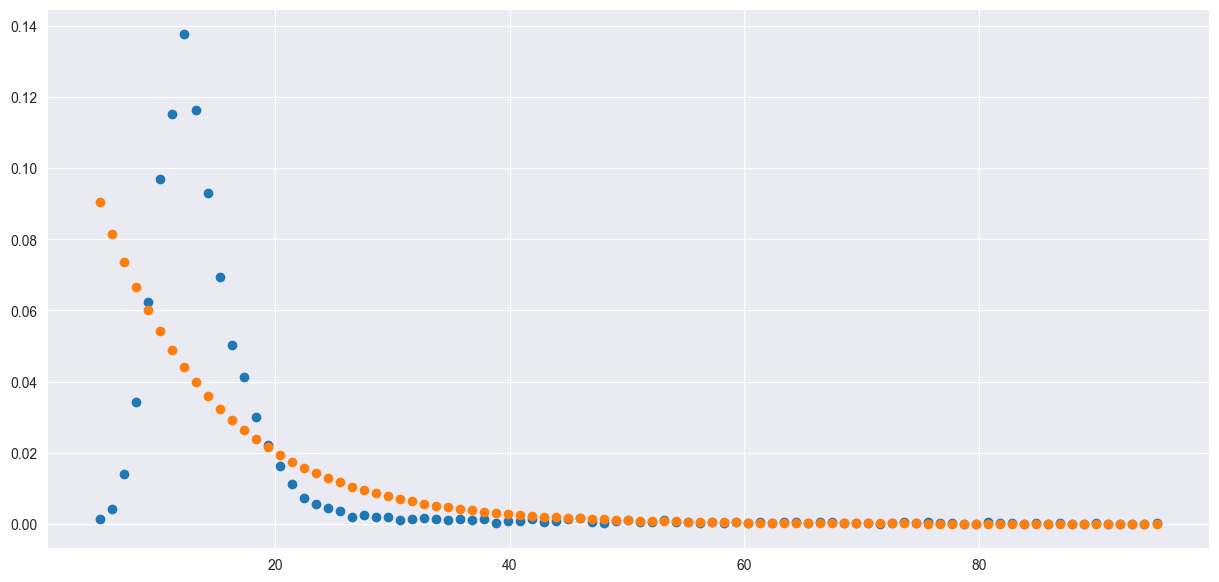

In [37]:
X, y = setupDf("clusters/artificial/cluto-t8-8k.arff")
endResults = outputResultsArt(X, y,checkValue=8)
printResults(endResults)
goodnessOfFit(X, y, 11)